Use the stream modes updates and values to stream the state of the graph as it executes.

- `updates` streams the updates to the state after each step of the graph.
- `values` streams the full value of the state after each step of the graph.

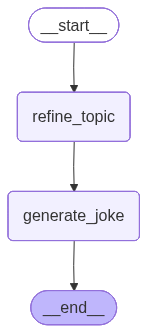

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


class State(TypedDict):
  topic: str
  joke: str


def refine_topic(state: State):
    return {"topic": state["topic"] + " and cats"}


def generate_joke(state: State):
    return {"joke": f"This is a joke about {state['topic']}"}

graph = (
  StateGraph(State)
  .add_node(refine_topic)
  .add_node(generate_joke)
  .add_edge(START, "refine_topic")
  .add_edge("refine_topic", "generate_joke")
  .add_edge("generate_joke", END)
  .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

#### Updates

In [ ]:
for chunk in graph.stream(
    {"topic": "ice cream"}, # type: ignore
    stream_mode="updates",
    version="v2",
):
    if chunk["type"] == "updates":
        for node_name, state in chunk["data"].items():
            print(f"Node `{node_name}` updated: {state}")

Node `refine_topic` updated: {'topic': 'ice cream and cats'}
Node `generate_joke` updated: {'joke': 'This is a joke about ice cream and cats'}


#### Values

In [ ]:
for chunk in graph.stream(
    {"topic": "ice cream"}, # type: ignore
    stream_mode="values",
    version="v2",
):
    if chunk["type"] == "values":
        print(chunk['data'])

{'topic': 'ice cream'}
{'topic': 'ice cream and cats'}
{'topic': 'ice cream and cats', 'joke': 'This is a joke about ice cream and cats'}
